# Notebook OBjectives

 - Handle Data that is across different experiments (numbers of latents)
 - Nominally these are:
    - PLotting of loss as a function of latent dimension
    - Creating super trajectories for making movies of reconstruction

In [1]:
import json, os, jax, glob
import jax.numpy as jnp
import mdtraj as md
import matplotlib.pyplot as plt
from pyscripts.analysis import NN_Experiment_Analyzer

jax:    0.4.25
jaxlib: 0.4.23.dev20240229
numpy:  1.26.4
python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
jax.devices (1 total, 1 local): [cuda(id=0)]
process_count: 1
platform: uname_result(system='Linux', node='normally-nefarious-noun', release='5.15.0-105-generic', version='#115-Ubuntu SMP Mon Apr 15 09:52:04 UTC 2024', machine='x86_64')


$ nvidia-smi
Tue Apr 30 19:55:18 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|================================

In [56]:
def atom_rmsd(a, b, potential_coefficient=None): # for arrays of (n_conf, n_atom*3)
    mn = a.shape[-1]//3
    x_inds, y_inds, z_inds = jnp.arange(0,mn), jnp.arange(mn, 2*mn), jnp.arange(2*mn, 3*mn)
    return jnp.sqrt(jnp.mean((b[x_inds] - a[x_inds])**2 + (b[y_inds] - a[y_inds])**2 + (b[z_inds] - a[z_inds])**2))

class NN_Multi_Analyzer():
    def __init__(self, json_params_series:[dict], netcdf_fns:[str], checkpoint_dirs:[str]):
        assert len(json_fns) == len(netcdf_fns)
        assert len(json_fns) == len(checkpoint_dirs)

        self.experiments = {}

        for i in range(len(netcdf_fns)):
            exp = NN_Experiment_Analyzer(json_params_series[i], netcdf_fns[i], checkpoint_dirs[i])
            key = f"{exp.n_latents} Latents"
            self.experiments[key] = exp

    def super_traj_construct(self, rng_seed, n_frames=500, mode='Decoded', num_components=None):
        """
        Creates two trajectories, which can be simultaneously visualized to see reconstruction with different numbers of latents

        Parameters:
            n_frames: The number of frames from each set to use, will be a slice of every x frames of the test data such that there are n_frames
                      i.e. if test_data is size 2000, and 500 frames are requested, every fourth frame of the test set will be shown
            mode: string in ['Decoded', 'Modeled'] : If Decoded, the super traj will contain frames that were encoded and decoded by the NN
                                                     If Modeled, the super traj will contain frames generated by GMM
            num_components: if not None, must be a list of integers the same length as the number of experiments
                            Will generate samples from the Gaussian Mixture Model to compare to
        """
        assert mode in ['Decoded', 'Modeled']
        #Since all experiments should have the same numbers of dimensions in this analysis, the atomistic size will be obtained from only one
        #size_test_set = pass
        num_experiments = len(self.experiments)
        if mode == 'Modeled':
            assert num_components is not None
            assert type(num_components) == list
            assert len(num_components) == num_experiments
            assert False not in [type(num) == int for num in num_components]
        num_test_set, num_dimensions = list(self.experiments.values())[0].test_data.shape
        #print(num_test_set, num_dimensions)
        assert num_test_set % n_frames == 0
        super_traj_test = jnp.zeros((n_frames*num_experiments, num_dimensions))
        super_traj_comp = jnp.zeros((n_frames*num_experiments, num_dimensions))

        for i in range(num_experiments):
            indices = jnp.arange(0, num_test_set, num_test_set//n_frames)
            #print(indices.shape)
            #print(indices)
            test_data = list(self.experiments.values())[i].test_data
            super_traj_test = super_traj_test.at[i*n_frames:(i+1)*n_frames, :].set(test_data[indices, :])

            if mode == 'Decoded':
                comp_data, _ = list(self.experiments.values())[i].operate(rng_seed)
            elif mode == 'Modeled':
                _, comp_data = list(self.experiments.values())[i].gaussian_mm_fit(rng_seed, num_components[i])

            super_traj_comp = super_traj_comp.at[i*n_frames:(i+1)*n_frames, :].set(comp_data[indices, :])

        assert not jnp.any(super_traj_comp == 0.0) and not jnp.any(super_traj_test == 0.0)
        return super_traj_test, super_traj_comp

    def rmsd_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, rmsds = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
        latents, rmsds = jnp.array(latents), jnp.array(rmsds)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('RMSD (Angstrom)')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()
            
        

In [61]:
json_wildcard = 'Bridges2_Runs/4_24_24/jsons/DA*1.json'
json_fns = sorted(glob.glob(json_wildcard))

nc_wildcard = 'Bridges2_Runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_1/*checkpoint.nc'
netcdf_fns = sorted(glob.glob(nc_wildcard))

ckpt_wildcard = 'Bridges2_Runs/4_24_24/DA_AE_Dropout_RMSD_only/*/rpt_1/checkpoint_managed/*/default/'
all_checkpoint_dirs = sorted(glob.glob(ckpt_wildcard))
checkpoint_dirs = []
#Two checkpoints per model, always take the latest one
indices = range(1, len(all_checkpoint_dirs)+1, 2)
for ind in indices:
    checkpoint_dirs.append(all_checkpoint_dirs[ind])

assert len(json_fns) == len(netcdf_fns)
assert len(json_fns) == len(checkpoint_dirs)

In [62]:
json_params_series = []
for json_fn in json_fns:
    #Json files were on Bridges2, doctor for this analysis
    with open(json_fn, 'r') as f:
        json_params = json.load(f)
    #print(json_params)
    #the json is from bridges, change file paths to be from jetstream
    #/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
    for key in ["fname_dcd", "fname_prmtop", "save_dir"]:
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/josephdb/",
                                                    "/media/volume/Boltzmann2Boltzmann/")
        #print(os.path.isfile(json_params[key]))
    #print(json_params)
    json_params_series.append(json_params)

In [63]:
self = NN_Multi_Analyzer(json_params_series, netcdf_fns, checkpoint_dirs)

Load Files
{'fname_dcd': '/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/Simulation/decaalanine_1us_split7.dcd', 'fname_prmtop': '/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/Simulation/ala_deca_peptide.prmtop', 'fname_pdb': 'None', 'save_dir': '/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/', 'data_dir': 'None', 'max_epoch': 100000, 'latent_dim': 2, 'test_slice': 1, 'data_slice_start': 0, 'data_slice_end': 'None', 'model_name': 'DA_AE_Dropout_RMSD_only', 'batch_size': 2000, 'learning_rate': 1e-06, 'dropout_rates': [0.1, 0.1, 0.1], 'potential_threshold': 0.05, 'model_type': 'AE', 'coordinate_scheme': 'Cartesian', 'resume_latest': False}
Load Data with MDTraj
Batch data
(8000, 306) (2000, 306)
Model Init
Batch Data
Read NetCDF and Checkpoint
Load Files
{'fname_dcd': '/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/Simulation/decaalanine_1us_split7.dcd', 'fname_prmtop': '/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/Simulation/ala_deca_peptide.prmtop', 'fname_pdb':

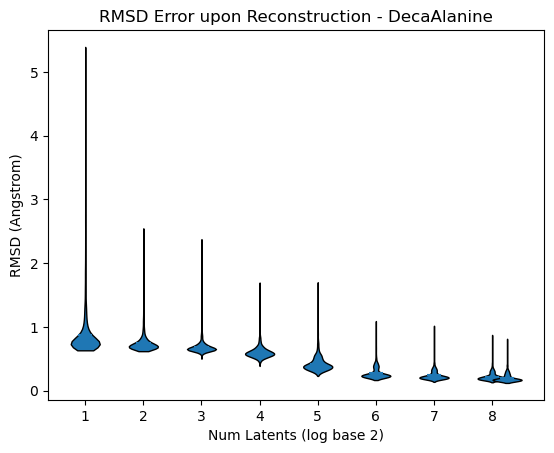

In [64]:
self.rmsd_violin_plot(rng_seed=98263, title='RMSD Error upon Reconstruction - DecaAlanine')

In [7]:
A, B = self.super_traj_construct()

In [9]:
rmsd = jax.vmap(atom_rmsd)(A, B)

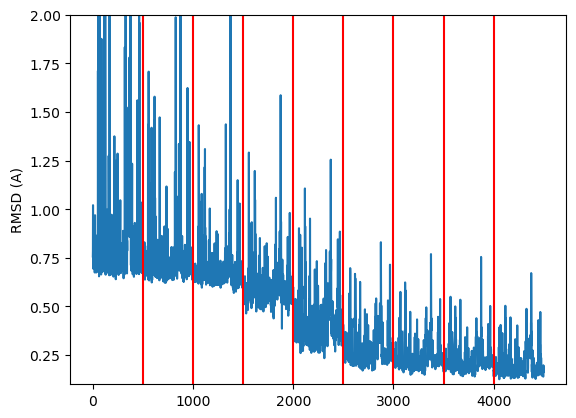

In [13]:
plt.clf()
_ = plt.plot(jnp.arange(rmsd.shape[0]), rmsd*10)
plt.vlines(jnp.array((500,1000,1500,2000,2500,3000,3500,4000)), jnp.array([0.025]*8), jnp.array([2.5]*8), colors='r')
plt.ylabel('RMSD (A)')
plt.ylim(0.1, 2)
plt.show()

In [12]:
def write_traj(fname, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    
    with md.formats.DCDTrajectoryFile(fname, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)

In [9]:
write_traj('Test_Data_Super.dcd', A)
write_traj('Decoded_Data_Super.dcd', B)

In [1]:
#Write a PDB for visualization with OpenMM

In [25]:
from openmm import *
from openmm.app import *
from openmm.unit import *

In [21]:
prmtop = AmberPrmtopFile('Simulation/1crn_H.prmtop')

In [15]:
positions = A[0, :].reshape(-1, 3)

In [26]:
with open('1crn_H.pdb', 'w') as f:
    PDBFile.writeModel(prmtop.topology, positions*10, file=f)